# Netflix Data Analysis & Recommendation System

## Project Overview

This project analyzes Netflix movies and TV shows to understand content trends, generes, countries, rating, and other patterns.

The project will also explore a recommendation system using machine learning techniques.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Netflix.csv")

## Dataset Overview
In this section, we will explore the structure and basic characteristics of the netflix dataset before performing data cleaning and analysis.

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,14-Aug-20,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,15-Dec-17,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,5-Jan-19,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,1-Mar-16,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...
4,s1001,TV Show,Blue Planet II,NaN,David Attenborough,United Kingdom,3-Dec-18,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...


In [4]:
df.shape

(7787, 12)

In [5]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genres', 'description'],
      dtype='str')

# Understanding the Dataset
Let's examine the data types, non-null values, and overall structure of the dataset.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       7787 non-null   str  
 1   type          7787 non-null   str  
 2   title         7787 non-null   str  
 3   director      5398 non-null   str  
 4   cast          7069 non-null   str  
 5   country       7280 non-null   str  
 6   date_added    7777 non-null   str  
 7   release_year  7787 non-null   int64
 8   rating        7780 non-null   str  
 9   duration      7787 non-null   int64
 10  genres        7787 non-null   str  
 11  description   7787 non-null   str  
dtypes: int64(2), str(10)
memory usage: 730.2 KB


# Missing values Analysis
Let's identify the number of missing values present in each column.

In [7]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
genres             0
description        0
dtype: int64

# Duplicate Records
Let's check wheather the dataset contains any duplicate rows.

In [8]:
df.duplicated().sum()

np.int64(0)

# Statistical Summary
Let's examine the statistical summary of the numerical columns.

In [9]:
df.describe()

,release_year,duration
count,7787.000000,7787.000000
mean,2013.932580,69.122769
std,8.757395,50.950743
min,1925.000000,1.000000
25%,2013.000000,2.000000
50%,2017.000000,88.000000
75%,2018.000000,106.000000
max,2021.000000,312.000000


# Filling Missing Categorical values

In [11]:
df["director"]=df["director"].fillna("Unknown")
df["cast"]=df["cast"].fillna("Unknown")
df["country"]=df["country"].fillna("Unknown")

# Exploratory data analysis

In this section, we willexplore the netflix dataset to identify patterns,trend, distributions, and features

1- Movies vs TV Shows

In [12]:
df["type"].value_counts()

type
Movie      5377
TV Show    2410
Name: count, dtype: int64

The chart shows the distribution of movies and TV shows in the Netflix Dataset.

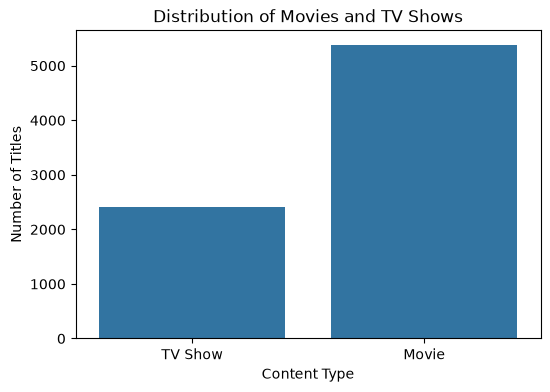

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x="type")
plt.title("Distribution of Movies and TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.show()

2- Netflix Content by Release Year
Let's analyze how the number of Netflix titles varies across different years.

In [14]:
yearly_content=df["release_year"].value_counts().sort_index()
yearly_content.tail(20)

release_year
2002      45
2003      49
2004      59
2005      73
2006      85
2007      85
2008     125
2009     137
2010     173
2011     166
2012     219
2013     267
2014     334
2015     541
2016     882
2017    1012
2018    1121
2019     996
2020     868
2021      31
Name: count, dtype: int64

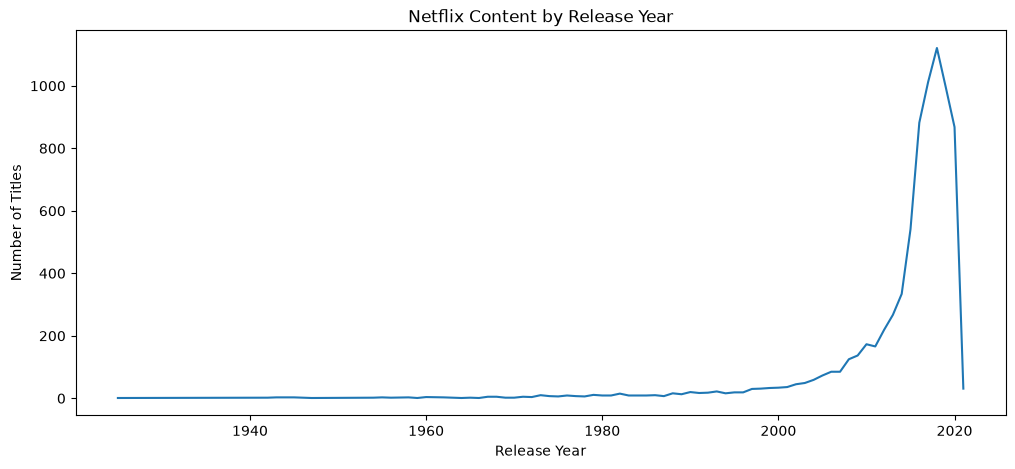

In [15]:
plt.figure(figsize=(12, 5))

plt.plot(yearly_content.index, yearly_content.values)

plt.title("Netflix Content by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

3- Distribution of Content Ratings
Let's identify the most common content ratings in the Netflix dataset

In [16]:
df["rating"].value_counts().head(10)

rating
TV-MA    2863
TV-14    1931
TV-PG     806
R         665
PG-13     386
TV-Y      280
TV-Y7     271
PG        247
TV-G      194
NR         84
Name: count, dtype: int64

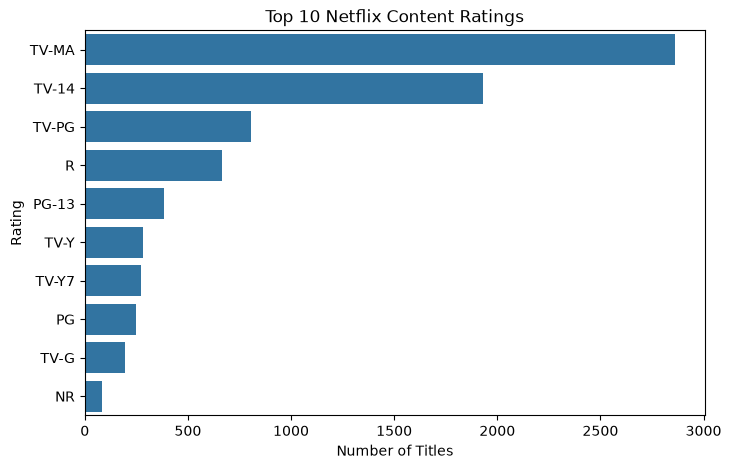

In [17]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    y="rating",
    order=df["rating"].value_counts().head(10).index
)

plt.title("Top 10 Netflix Content Ratings")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")

plt.show()

4- Movies vs TV Shows over time
Let's compare the release-year trends of Movies and TV Shows.

In [18]:
content_by_year=df.groupby(["release_year","type"]).size().unstack(fill_value=0)
content_by_year.tail(20)

type,Movie,TV Show
release_year,,
2002,39,6
2003,40,9
2004,50,9
2005,61,12
2006,72,13
2007,72,13
2008,102,23
2009,103,34
2010,136,37


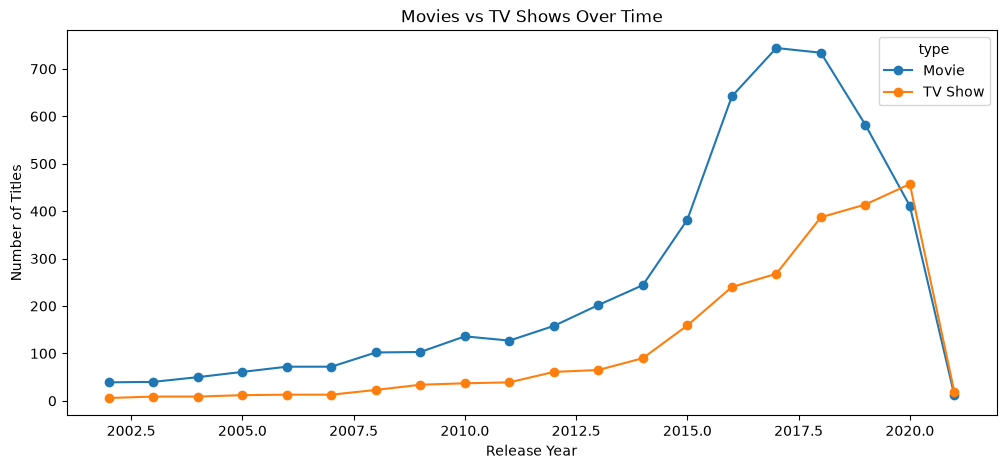

In [20]:
content_by_year.tail(20).plot(
    figsize=(12, 5),
    marker="o"
)
plt.title("Movies vs TV Shows Over Time")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

5- Top Countries by Number of Titles
Let's identify the countries with the highest number of titles in the Netflix dataset

In [21]:
df["country"].value_counts().head(10)

country
United States     2555
India              923
Unknown            507
United Kingdom     397
Japan              226
South Korea        183
Canada             177
Spain              134
France             115
Egypt              101
Name: count, dtype: int64

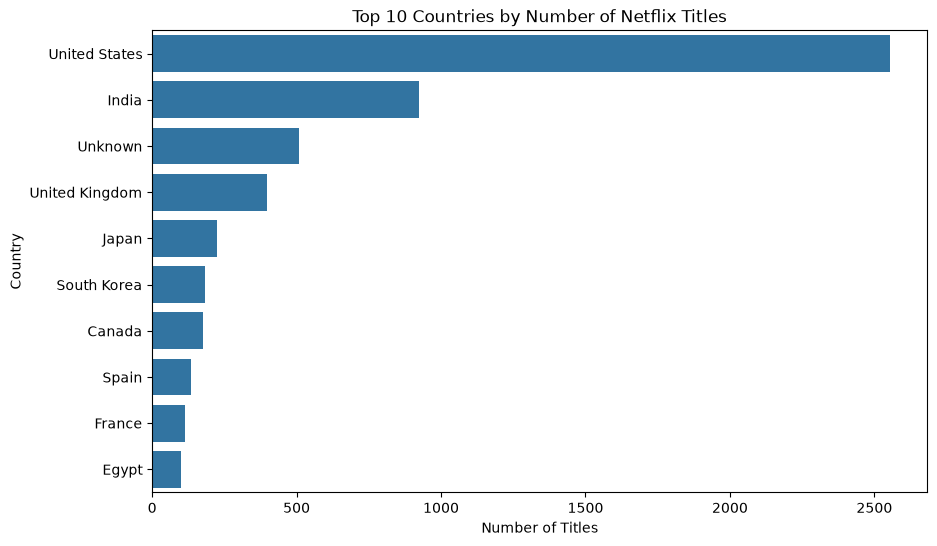

In [22]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y="country",
    order=df["country"].value_counts().head(10).index
)

plt.title("Top 10 Countries by Number of Netflix Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

# Genre Analysis
Let's identify the most common genres available in the Netflix dataset

In [27]:
genre_counts = (
    df["genres"]
    .str.split(", ")
    .explode()
    .value_counts()
)

genre_counts.head(10)

genres
International Movies        2437
Dramas                      2106
Comedies                    1471
International TV Shows      1199
Documentaries                786
Action & Adventure           721
TV Dramas                    704
Independent Movies           673
Children & Family Movies     532
Romantic Movies              531
Name: count, dtype: int64

Text(0, 0.5, 'Genere')

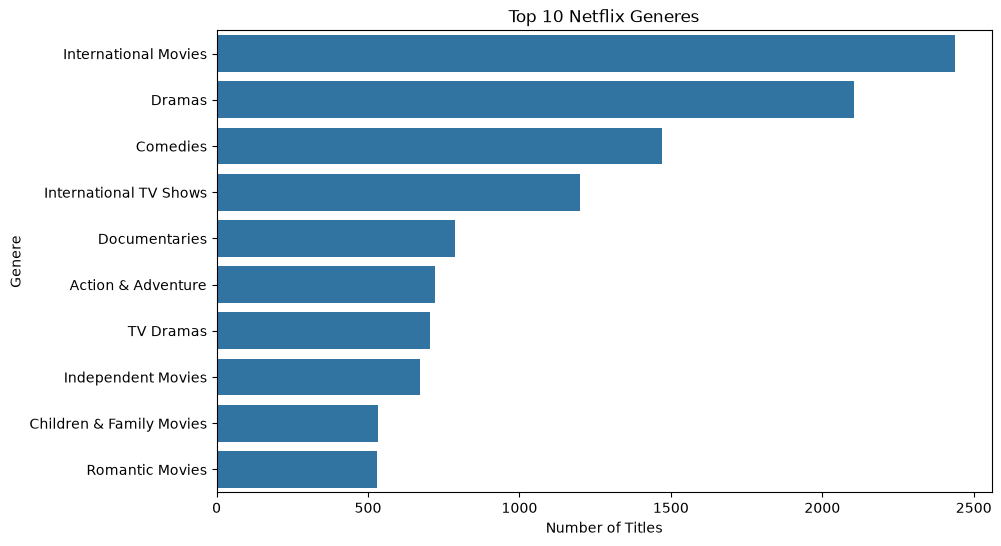

In [29]:
plt.figure(figsize=(10,6))
sns.barplot(
    x=genre_counts.head(10).values,
    y=genre_counts.head(10).index
)
plt.title("Top 10 Netflix Generes")
plt.xlabel("Number of Titles")
plt.ylabel("Genere")

# Content Duration Analysis
Let's examine the duration of Netflix Movies and TV Shows

In [31]:
df["duration"].value_counts().head(15)

duration
1      1608
2       382
3       185
90      136
93      131
94      125
91      125
95      119
92      118
97      117
96      115
98      106
99      101
88      101
103     101
Name: count, dtype: int64

# Movies's Duration Analysis
For Movies, duration is recorded in minutes. We will extract the numeric duration to analyze the typical length of Netflix Movies.

In [33]:
movie_duration = df.loc[df["type"] == "Movie", "duration"].astype("string")

movie_duration = movie_duration.str.replace(" min", "", regex=False)

movie_duration = pd.to_numeric(movie_duration, errors="coerce")

movie_duration.describe()

count       5377.0
mean     99.307978
std      28.530881
min            3.0
25%           86.0
50%           98.0
75%          114.0
max          312.0
Name: duration, dtype: Float64

# Distribution of Movie Duration
let's visualize the distribution of movie durations.

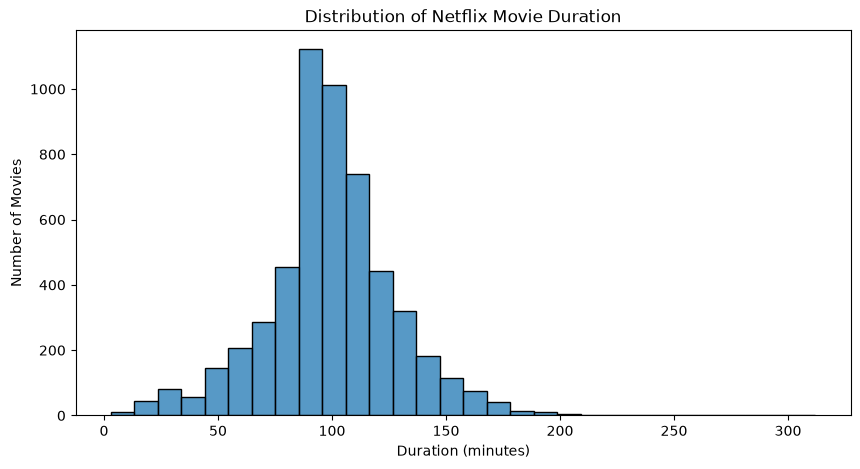

In [34]:
plt.figure(figsize=(10, 5))

sns.histplot(movie_duration.dropna(), bins=30)

plt.title("Distribution of Netflix Movie Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")

plt.show()

 # India-specific Analysis
Let's identify Netflix titles associated with India and analyze their distribution by content type

In [35]:
india_content=df[df["country"].str.contains("India", case=False, na=False)]
india_content.shape

(990, 12)

In [36]:
india_content["type"].value_counts()

type
Movie      915
TV Show     75
Name: count, dtype: int64

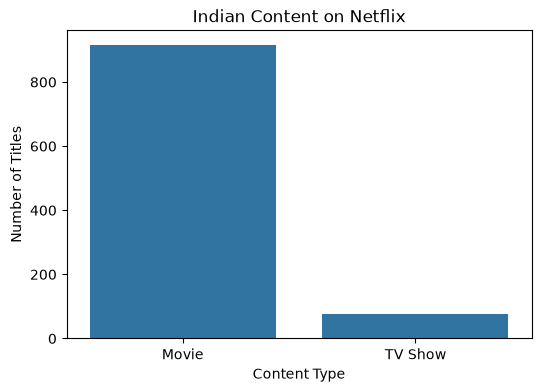

In [37]:
plt.figure(figsize=(6, 4))

sns.countplot(data=india_content, x="type")

plt.title("Indian Content on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.show()

## Feature Engineering
Feature engineering is the process of creating and transforming
features from the existing data to make them more useful for
machine learning.

For the recommendation system, we will combine relevant textual
features such as genres, director, cast, country, and description.

In [39]:
feature_columns=[
    "title",
    "director",
    "cast",
    "country",
    "genres",
    "description"
]
df[feature_columns].head()

,title,director,cast,country,genres,description
0,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...
2,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...
3,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,Comedies,New NFL star Thad buys his old teammates' belo...
4,Blue Planet II,Unknown,David Attenborough,United Kingdom,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...


# Handling Missing Text Features
Missing values in text-based features can cause problems during
text processing. We will replace missing values with empty strings
before combining the features.

In [41]:
text_features = [
    "director",
    "cast",
    "country",
    "genres",
    "description"
]

df[text_features] = df[text_features].fillna("")

# Creating a Combined Feature
We will combine the important content-related features into a single
text feature. This combined feature will later be converted into
numerical vectors using TF-IDF.

In [42]:
df["combined_features"] = (
    df["director"] + " " +
    df["cast"] + " " +
    df["country"] + " " +
    df["genres"] + " " +
    df["description"]
)

In [43]:
df[["title","combined_features"]].head()

,title,combined_features
0,3%,"Unknown João Miguel, Bianca Comparato, Michel ..."
1,1920,"Vikram Bhatt Rajneesh Duggal, Adah Sharma, Ind..."
2,3 Heroines,"Iman Brotoseno Reza Rahadian, Bunga Citra Lest..."
3,Blue Mountain State: The Rise of Thadland,"Lev L. Spiro Alan Ritchson, Darin Brooks, Jame..."
4,Blue Planet II,Unknown David Attenborough United Kingdom Brit...


## 7. Text Vectorization using TF-IDF

TF-IDF (Term Frequency-Inverse Document Frequency) converts textual
information into numerical vectors.

We will use TF-IDF to represent the combined content features of
Netflix titles so that similarity between titles can be calculated.

In [47]:
%pip install -U scikit-learn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.3 MB 8.3 MB/s eta 0:00:01
   --------------- ------------------------ 3.1/8.3 MB 7.4 MB/s eta 0:00:01
   ---------------------- ----------------- 4.7/8.3 MB 7.5 MB/s eta 0:00:01
   ------------------------------- -------- 6.6/8.3 MB 7.6 MB/s eta 0:00:01
   ------------------------------------ --- 7.6/8.3 MB 7.5 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 6.6 MB/s  0:00:01
   ---------------------------------------- 0.0/37.4 MB ? eta -:--:--
   - -------------------------------------- 1.3/37.4 MB 8.0 MB/s eta 0:00:05
   - -------------------------------------- 1.8/37.4 MB 4.3 MB/s eta 0:00:09
   -- ------------------------------------- 2.4/37.4 MB 3.5 MB/s eta 0:00:10
   --- ------------------------------------ 2.9/37.4 MB 3.6 MB/s eta 0:00:10
   --- ------------------------------------ 3.7/37.4 MB 3.5 MB/s eta 0:00:10
   ----- --------------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
import sklearn

print(sklearn.__version__)

1.9.0


In [49]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 7 Creating TF-IDF Vectors

We will transform the combined text features into TF-IDF vectors.

In [50]:
tfidf = TfidfVectorizer(stop_words="english")

tfidf_matrix = tfidf.fit_transform(df["combined_features"])

In [51]:
TfidfVectorizer()

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1

In [52]:
stop_words="english"

# 7.2 Checking the TF-IDF Matrix

Let's check the dimensions of the generated TF-IDF matrix.

In [54]:
tfidf_matrix.shape

(7787, 46377)

# 8. Calculating Cosine Similarity

Cosine similarity measures how similar two content vectors are.

A higher similarity score means that two Netflix titles have more
similar content-related features.

In [55]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix)

In [56]:
cosine_sim.shape

(7787, 7787)

# 9. Building the Recommendation System

We will create a function that takes a Netflix title as input
and returns the most similar titles based on their content features.

In [57]:
indices = pd.Series(df.index, index=df["title"]).drop_duplicates()

# 9.1 Recommendation Function

The recommendation function will find the selected title,
compare its similarity scores with other titles, and return
the most similar Netflix titles.

In [58]:
def recommend(title, n=5):
    if title not in indices:
        return "Title not found in the dataset."

    idx = indices[title]

    similarity_scores = list(enumerate(cosine_sim[idx]))

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:n+1]

    movie_indices = [i[0] for i in similarity_scores]

    return df.iloc[movie_indices][["title", "type", "genres"]]

Let's test the recommendation system using a Netflix title.

In [59]:
recommend("Blue Mountain State: The Rise of Thadland")

,title,type,genres
6009,"The Goods: Live Hard, Sell Hard",Movie,Comedies
4566,"Ray Romano: Right Here, Around the Corner",Movie,Stand-Up Comedy
2653,Killer Inside: The Mind of Aaron Hernandez,TV Show,"Crime TV Shows, Docuseries"
1694,Grease,Movie,"Classic Movies, Comedies, Music & Musicals"
394,Chris D'Elia: Incorrigible,Movie,Stand-Up Comedy


# 10. Testing the Recommendation System

We will test the recommendation system with different Netflix titles
to check whether the returned recommendations are relevant and
similar to the selected title.

In [60]:
df["title"].sample(10, random_state=42).tolist()

['Whindersson Nunes: Adult',
 'Rita',
 'FirstBorn',
 'Si Doel the Movie 3',
 '3Below: Tales of Arcadia',
 'Muran',
 'Mojave',
 'Club Friday To Be Continued - The Promise',
 'The Great British Baking Show: The Beginnings',
 'Marlon Wayans: Woke-ish']

In [62]:
recommend("Club Friday To Be Continued - The Promise", n=5)

,title,type,genres
3954,"O-Negative, Love Can’t Be Designed",TV Show,"International TV Shows, Romantic TV Shows, TV ..."
484,Club Friday The Series 8,TV Show,"International TV Shows, Romantic TV Shows, TV ..."
3402,Mexico Diseña,TV Show,"International TV Shows, Reality TV, Spanish-La..."
1266,Fear Files... Har Mod Pe Darr,TV Show,"International TV Shows, TV Horror, TV Thrillers"
658,Dancing Angels,TV Show,"International TV Shows, Romantic TV Shows, TV ..."


In [63]:
recommend("3 Heroines", n=5)

,title,type,genres
1749,Habibie & Ainun,Movie,"Dramas, International Movies, Romantic Movies"
3735,My Stupid Boss 2,Movie,"Comedies, International Movies"
3733,My Stupid Boss,Movie,"Comedies, International Movies"
4772,Rudy Habibie,Movie,"Dramas, International Movies"
2570,Kartini: Princess of Java,Movie,"Dramas, International Movies"


# 11. Unsupervised Machine Learning: K-Means Clustering

K-Means clustering is an unsupervised machine learning algorithm
that groups similar observations into clusters.

We will use the TF-IDF representation of Netflix content to explore
whether titles can be grouped based on their textual content. 

In [65]:
from sklearn.cluster import KMeans

# 11.1 Creating Content Clusters

We will divide the Netflix titles into 5 clusters based on their
TF-IDF features.

In [66]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(tfidf_matrix)

In [67]:
df["cluster"].value_counts().sort_index()

cluster
0     187
1    1689
2    2690
3    2040
4    1181
Name: count, dtype: int64

In [68]:
df[["title", "type", "genres", "cluster"]].sort_values("cluster").head(30)

,title,type,genres,cluster
4592,Record of Youth,TV Show,"International TV Shows, Romantic TV Shows, TV ...",0
7743,28 Moons,TV Show,"International TV Shows, Korean TV Shows, Roman...",0
4628,Reply 1997,TV Show,"International TV Shows, Korean TV Shows, Roman...",0
1928,High Society,Movie,"Dramas, International Movies",0
1870,Heaven's Garden,TV Show,"International TV Shows, Korean TV Shows, TV Dr...",0
1913,Hidden Singer,TV Show,"International TV Shows, Korean TV Shows, Reali...",0
6463,The Reservoir Game,Movie,"Documentaries, International Movies",0
6427,The Prison,Movie,"Action & Adventure, Dramas, International Movies",0
2017,Hospital Playlist,TV Show,"International TV Shows, Korean TV Shows, TV Co...",0
6542,The Sound of Your Heart,TV Show,"International TV Shows, Korean TV Shows, TV Co...",0


# 12. Visualizing Content Clusters

We will visualize the Netflix content clusters using a two-dimensional
representation of the TF-IDF features.

In [70]:
from sklearn.decomposition import PCA

# 12.1 Reducing TF-IDF Dimensions

TF-IDF produces a high-dimensional matrix. PCA will reduce the
dimensions to two components so that the clusters can be visualized.

In [71]:
pca = PCA(n_components=2, random_state=42)

tfidf_2d = pca.fit_transform(tfidf_matrix.toarray())

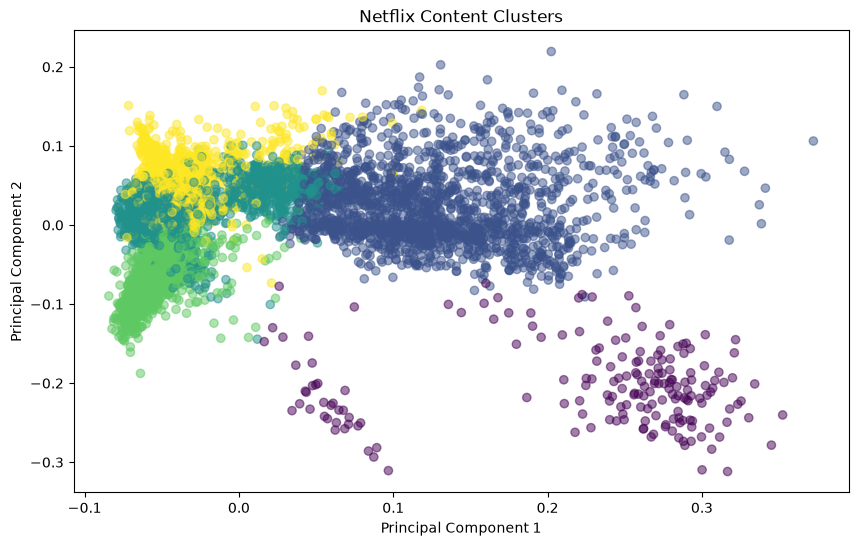

In [72]:
plt.figure(figsize=(10, 6))

plt.scatter(
    tfidf_2d[:, 0],
    tfidf_2d[:, 1],
    c=df["cluster"],
    alpha=0.5
)

plt.title("Netflix Content Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

# 12.2 Understanding Cluster Characteristics
We will examine the most common genres  within each cluster to understand what type of Netflix content  each cluster represents.

In [73]:
for cluster in sorted(df["cluster"].unique()):
    print(f"\nCluster {cluster}")
    
    genres = (
        df.loc[df["cluster"] == cluster, "genres"]
        .dropna()
        .str.split(", ")
        .explode()
        .value_counts()
        .head(5)
    )
    
    print(genres)


Cluster 0
genres
International TV Shows    141
Korean TV Shows           134
Romantic TV Shows          75
International Movies       32
TV Dramas                  26
Name: count, dtype: int64

Cluster 1
genres
International TV Shows    1047
TV Dramas                  595
Crime TV Shows             400
TV Comedies                358
Docuseries                 271
Name: count, dtype: int64

Cluster 2
genres
Dramas                      815
Comedies                    708
Action & Adventure          490
Children & Family Movies    464
Independent Movies          401
Name: count, dtype: int64

Cluster 3
genres
International Movies    1901
Dramas                  1271
Comedies                 754
Romantic Movies          319
Independent Movies       271
Name: count, dtype: int64

Cluster 4
genres
Documentaries           732
Stand-Up Comedy         328
International Movies    224
Music & Musicals        120
Sports Movies            85
Name: count, dtype: int64


# 13. Model Evaluation and Limitations

The recommendation system is based on content similarity using
TF-IDF and cosine similarity.

Since this is a content-based recommendation system and there is no
user-rating or interaction data in the dataset, traditional
classification metrics such as accuracy, precision, and recall are
not directly applicable.

Therefore, recommendations will be evaluated qualitatively by
examining whether the recommended titles have similar genres,
cast, directors, countries, or descriptions.

13.1 Recommendation Example

Let's examine recommendations for a selected Netflix title and
manually assess whether the results are relevant.

In [74]:
title = df["title"].dropna().iloc[0]

print("Selected Title:", title)

recommend_with_scores(title, n=5)

Selected Title: 3%


,title,type,genres,similarity_score
0,All The Reasons To Forget,Movie,"Comedies, Dramas, International Movies",0.102
1,Blood Pact,TV Show,"Crime TV Shows, International TV Shows, TV Dramas",0.090
2,Lo que la verdad esconde: El caso Asunta (Oper...,TV Show,"Crime TV Shows, Docuseries, International TV S...",0.086
3,Lugar de Mulher,TV Show,"International TV Shows, Stand-Up Comedy & Talk...",0.086
4,Back with the Ex,TV Show,"International TV Shows, Reality TV, Romantic T...",0.085


# 14. Key Findings

The analysis of the Netflix dataset revealed several patterns
related to content type, release years, ratings, genres, countries,
and content added over time.

The machine learning section further demonstrated how textual
features can be transformed using TF-IDF and used to build a
content-based recommendation system.

# Machine Learning Findings

- TF-IDF was used to convert textual content into numerical vectors.
- Cosine similarity was used to measure similarity between Netflix titles.
- A content-based recommendation system was developed.
- K-Means clustering was used to group titles based on textual features.
- PCA was used to visualize the resulting clusters.

# Interactive Netflix Recommendation System

In [ ]:
def recommend(title, n=5):
    title = title.strip()

    matches = df[
        df["title"].str.lower() == title.lower()
    ]

    if matches.empty:
        return "Title not found in the dataset."

    idx = matches.index[0]

    similarity_scores = list(enumerate(cosine_sim[idx]))

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:n+1]

    movie_indices = [i[0] for i in similarity_scores]

    return df.iloc[movie_indices][
        ["title", "type", "genres"]
    ]

In [75]:
movie_name = input("Enter a Netflix title: ")
recommend_with_scores(movie_name)

KeyboardInterrupt: Interrupted by user

# 16. Project Conclusion

This project explored the Netflix dataset through data cleaning,
exploratory data analysis, feature engineering, and machine learning.

Key techniques used in this project include:

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- TF-IDF Vectorization
- Cosine Similarity
- K-Means Clustering
- PCA

The project resulted in a content-based Netflix recommendation system
that recommends similar titles based on their content features.

K-Means clustering was also used to explore groups of similar Netflix
titles.

# Limitations

The dataset does not contain user ratings, viewing history, or user-item
interaction data. Therefore, the recommendation system is based on
content similarity rather than collaborative filtering.

The recommendations should therefore be interpreted as
content-based suggestions rather than predictions of user preference.

17. Exporting Recommendation Results

The recommendation results generated by the content-based
recommendation system will be exported into a structured CSV file.

This file will later be used in the Power BI dashboard to display
recommendation insights.

In [77]:
# Create recommendation results for every Netflix title

recommendation_results = []

for title in df["title"].dropna().unique():
    idx = indices[title]

    similarity_scores = list(enumerate(cosine_sim[idx]))

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # Remove the title itself and keep top 5 recommendations
    similarity_scores = similarity_scores[1:6]

    for movie_idx, score in similarity_scores:
        recommendation_results.append({
            "Title": title,
            "Recommended_Title": df.iloc[movie_idx]["title"],
            "Type": df.iloc[movie_idx]["type"],
            "Genres": df.iloc[movie_idx]["genres"],
            "Similarity_Score": round(score, 3)
        })

recommendations_df = pd.DataFrame(recommendation_results)

recommendations_df.head()

,Title,Recommended_Title,Type,Genres,Similarity_Score
0,3%,All The Reasons To Forget,Movie,"Comedies, Dramas, International Movies",0.102
1,3%,Blood Pact,TV Show,"Crime TV Shows, International TV Shows, TV Dramas",0.090
2,3%,Lo que la verdad esconde: El caso Asunta (Oper...,TV Show,"Crime TV Shows, Docuseries, International TV S...",0.086
3,3%,Lugar de Mulher,TV Show,"International TV Shows, Stand-Up Comedy & Talk...",0.086
4,3%,Back with the Ex,TV Show,"International TV Shows, Reality TV, Romantic T...",0.085


In [78]:
recommendations_df.to_csv(
    "Netflix_Recommendations.csv",
    index=False
)

print("Recommendation file created successfully.")


Recommendation file created successfully.
